In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import seaborn as sns
import math
import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
df = pd.read_csv('data/processed/train_FD001_processed.csv')

In [3]:
max_cycles = df.groupby('engine')['cycle'].max().to_dict()
df['max_cycle'] = df['engine'].map(max_cycles)
df['norm_RUL'] = df['cycle'] / df['max_cycle']

sensor_cols = [
    "Fan Inlet Temperature (°K)", "LPC Outlet Temperature (°K)", "HPC Outlet Temperature (°K)",
    "LPT Outlet Temperature (°K)", "Fan Inlet Pressure (kPa)", "Bypass-Duct Pressure (kPa)",
    "HPC Outlet Pressure (kPa)", "Physical Fan Speed (rpm)", "Physical Core Speed (rpm)",
    "Engine Pressure Ratio (P50/P2)", "HPC Outlet Static Pressure (kPa)",
    "Ratio of Fuel Flow to Ps30 (m²/s)", "Corrected Fan Speed (rpm)", "Corrected Core Speed (rpm)",
    "Bypass Ratio", "Burner Fuel-Air Ratio", "Bleed Enthalpy", "Required Fan Speed",
    "Required Fan Conversion Speed", "High-Pressure Turbines Cool Air Flow", "Low-Pressure Turbines Cool Air Flow"
]

window_size = 5
for sensor in sensor_cols:
    df[f'{sensor}_rolling_mean'] = df.groupby('engine')[sensor].transform(lambda x: x.rolling(window_size, min_periods=1).mean())
    df[f'{sensor}_rolling_std'] = df.groupby('engine')[sensor].transform(lambda x: x.rolling(window_size, min_periods=1).std())
df.fillna(0, inplace=True)

baseline = df.groupby('engine').head(5).groupby('engine')[sensor_cols].mean()
baseline.columns = [c + "_baseline" for c in baseline.columns]
df = df.join(baseline, on='engine', how='left')

for c in sensor_cols:
    df[c + "_delta"] = df[c] - df[c + "_baseline"]

print("Feature engineering complete.")

Feature engineering complete.


In [4]:
np.random.seed(42)
all_engines = df['engine'].unique()
np.random.shuffle(all_engines)

train_split = int(len(all_engines) * 0.70)
val_split = int(len(all_engines) * 0.85)

train_engines = all_engines[:train_split]
val_engines   = all_engines[train_split:val_split]
test_engines  = all_engines[val_split:]

train_df = df[df['engine'].isin(train_engines)].copy()
val_df   = df[df['engine'].isin(val_engines)].copy()
test_df  = df[df['engine'].isin(test_engines)].copy()

print(f"Data split into {len(train_engines)} training engines, {len(val_engines)} validation engines, and {len(test_engines)} test engines.")

# Define features, including 'cycle'
feature_cols = [c for c in df.columns if c not in ['engine','cycle','RUL', 'norm_RUL', 'max_cycle']]
feature_cols.append('cycle')

# Fit scaler ONLY on the training data
scaler = StandardScaler()
scaler.fit(train_df[feature_cols])

# Transform all three sets
train_df[feature_cols] = scaler.transform(train_df[feature_cols])
val_df[feature_cols]   = scaler.transform(val_df[feature_cols])
test_df[feature_cols]  = scaler.transform(test_df[feature_cols])

Data split into 70 training engines, 15 validation engines, and 15 test engines.


In [5]:
LOOKBACK = 60

def create_windows(data, lookback, features):
    X, y = [], []
    for eng in data['engine'].unique():
        d = data[data.engine == eng]
        for i in range(len(d)-lookback+1):
            X.append(d.iloc[i:i+lookback][features].values)
            y.append(d.iloc[i+lookback-1].norm_RUL)
    return np.array(X), np.array(y).reshape(-1,1)

X_train_np, y_train_np = create_windows(train_df, LOOKBACK, feature_cols)
X_val_np,   y_val_np   = create_windows(val_df, LOOKBACK, feature_cols)
X_test_np,  y_test_np  = create_windows(test_df, LOOKBACK, feature_cols)

print(f"Training windows: {X_train_np.shape}")
print(f"Validation windows: {X_val_np.shape}")
print(f"Test windows: {X_test_np.shape}")

Training windows: (10186, 60, 109)
Validation windows: (2285, 60, 109)
Test windows: (2260, 60, 109)


In [6]:
X_train = torch.from_numpy(X_train_np).float()
y_train = torch.from_numpy(y_train_np).float()
X_val   = torch.from_numpy(X_val_np).float()
y_val   = torch.from_numpy(y_val_np).float()
X_test  = torch.from_numpy(X_test_np).float()
y_test  = torch.from_numpy(y_test_np).float()

batch_size = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size)

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class CNNTransformerRUL(nn.Module):
    def __init__(self, input_dim, d_model, nhead, d_hid, nlayers, dropout):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_dim, d_model, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1), nn.ReLU()
        )
        self.pos = PositionalEncoding(d_model, dropout)
        enc_layer = nn.TransformerEncoderLayer(d_model, nhead, d_hid, dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, nlayers)
        self.post_norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model//2), nn.ReLU(),
            nn.Linear(d_model//2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.permute(0,2,1)
        x = self.cnn(x)
        x = x.permute(0,2,1)
        x = self.pos(x)
        x = self.transformer(x)
        x = self.post_norm(x)
        x = torch.mean(x, dim=1)
        return self.head(x)

model = CNNTransformerRUL(X_train.shape[2], 128, 8, 256, 4, 0.2).to(device)

In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5 / 3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.2, patience=5)

best_val = float('inf')
patience = 15
no_improve = 0
history = {'train':[], 'val':[]}

for epoch in range(1, 150):
    model.train()
    total_train_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_train_loss += loss.item()
    train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = model(Xb)
            total_val_loss += criterion(pred, yb).item()
    val_loss = total_val_loss / len(val_loader)

    history['train'].append(train_loss)
    history['val'].append(val_loss)
    print(f"Epoch {epoch:03d} | Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f}")
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        no_improve = 0
        print("✅ Saving Best Model")
    else:
        no_improve += 1

    if no_improve >= patience:
        print("❌ Early Stopping")
        break

model.load_state_dict(best_model_state)

Epoch 001 | Train Loss 0.0339 | Val Loss 0.0069
✅ Saving Best Model
Epoch 002 | Train Loss 0.0052 | Val Loss 0.0049
✅ Saving Best Model
Epoch 003 | Train Loss 0.0034 | Val Loss 0.0039
✅ Saving Best Model
Epoch 004 | Train Loss 0.0027 | Val Loss 0.0042
Epoch 005 | Train Loss 0.0023 | Val Loss 0.0041
Epoch 006 | Train Loss 0.0020 | Val Loss 0.0036
✅ Saving Best Model
Epoch 007 | Train Loss 0.0017 | Val Loss 0.0039
Epoch 008 | Train Loss 0.0016 | Val Loss 0.0036
✅ Saving Best Model
Epoch 009 | Train Loss 0.0014 | Val Loss 0.0033
✅ Saving Best Model
Epoch 010 | Train Loss 0.0012 | Val Loss 0.0035
Epoch 011 | Train Loss 0.0011 | Val Loss 0.0033
Epoch 012 | Train Loss 0.0010 | Val Loss 0.0032
✅ Saving Best Model
Epoch 013 | Train Loss 0.0009 | Val Loss 0.0033
Epoch 014 | Train Loss 0.0008 | Val Loss 0.0037
Epoch 015 | Train Loss 0.0008 | Val Loss 0.0033
Epoch 016 | Train Loss 0.0007 | Val Loss 0.0030
✅ Saving Best Model
Epoch 017 | Train Loss 0.0006 | Val Loss 0.0032
Epoch 018 | Train Loss 0

<All keys matched successfully>

In [9]:
def window_aligned_max_cycles(dataframe, lookback):
    out = []
    for eng in dataframe['engine'].unique():
        d = dataframe[dataframe.engine == eng]
        for i in range(len(d) - lookback + 1):
            out.append(d.iloc[i + lookback - 1].max_cycle)
    return np.array(out)

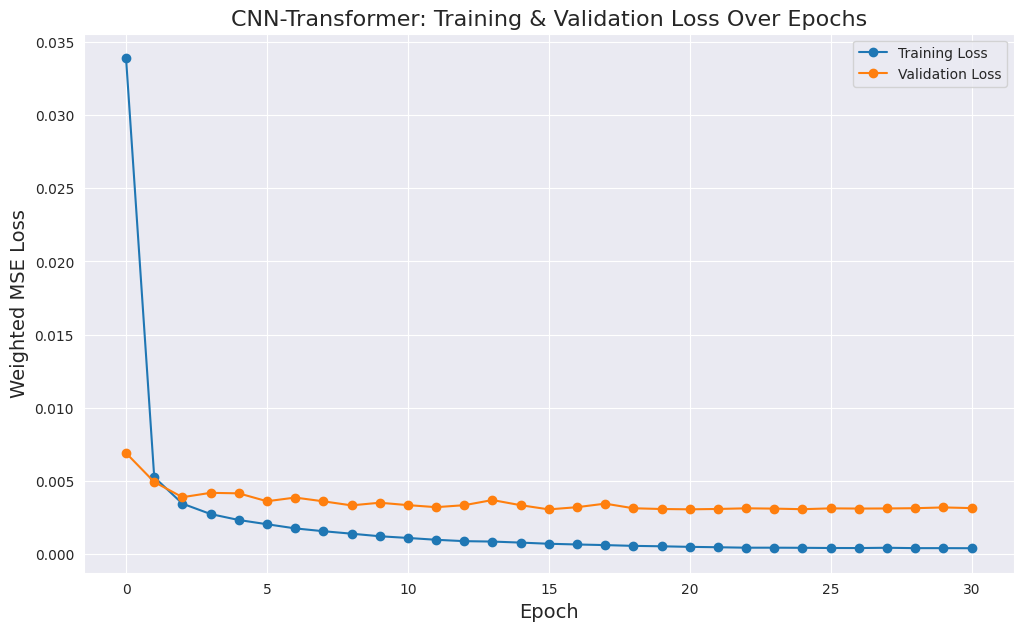

In [10]:
plt.figure(figsize=(12, 7))
plt.plot(history['train'], label='Training Loss', marker='o')
plt.plot(history['val'], label='Validation Loss', marker='o')
plt.title('CNN-Transformer: Training & Validation Loss Over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Weighted MSE Loss', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


--- Final Test Set Performance ---
Test MAE (normalized): 0.0360
Test RMSE (normalized): 0.0464



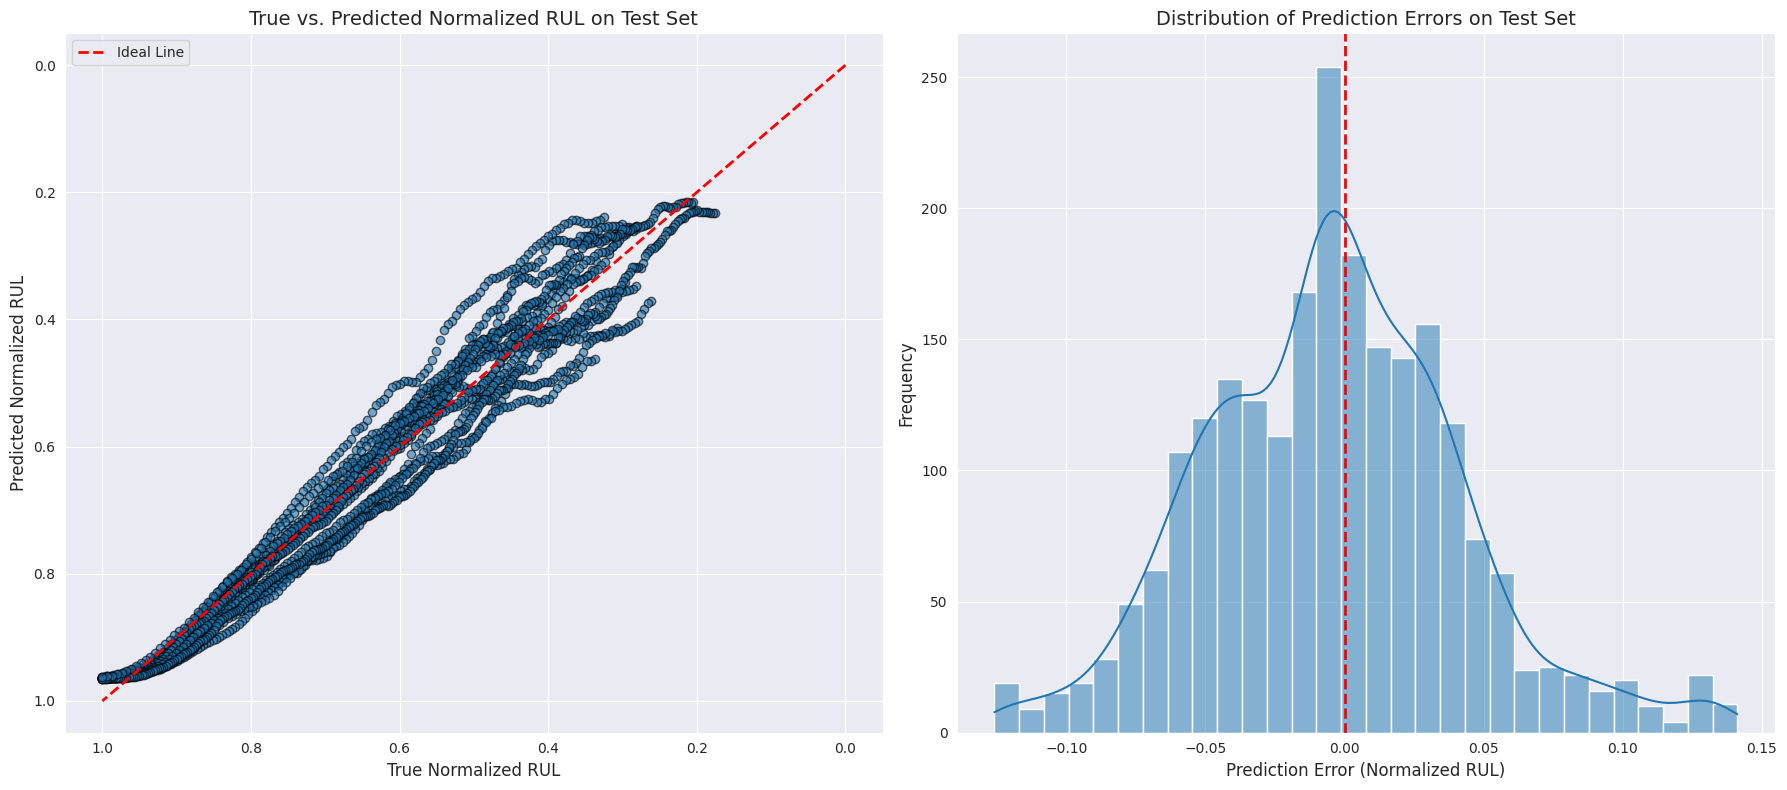

In [11]:
model.eval()
y_pred_list_test = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        batch_X = batch_X.to(device)
        output = model(batch_X)
        y_pred_list_test.append(output.cpu().numpy())

y_pred_test = np.concatenate(y_pred_list_test, axis=0).flatten()
y_test_np_flat = y_test_np.flatten()
mae_test = mean_absolute_error(y_test_np_flat, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test_np_flat, y_pred_test))

print("\n--- Final Test Set Performance ---")
print(f"Test MAE (normalized): {mae_test:.4f}")
print(f"Test RMSE (normalized): {rmse_test:.4f}\n")

plt.figure(figsize=(18, 8))
plt.subplot(1, 2, 1)
plt.scatter(y_test_np_flat, y_pred_test, alpha=0.6, edgecolors='k')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Ideal Line')
plt.title('True vs. Predicted Normalized RUL on Test Set', fontsize=14)
plt.xlabel('True Normalized RUL', fontsize=12)
plt.ylabel('Predicted Normalized RUL', fontsize=12)
plt.grid(True)
plt.legend()

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

errors_test = y_test_np_flat - y_pred_test
plt.subplot(1, 2, 2)
sns.histplot(errors_test, bins=30, kde=True)
plt.title('Distribution of Prediction Errors on Test Set', fontsize=14)
plt.xlabel('Prediction Error (Normalized RUL)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', lw=2)
plt.grid(True)
plt.tight_layout()
plt.show()


--- Validation Set Performance ---
Validation MAE (normalized): 0.0418
Validation RMSE (normalized): 0.0554



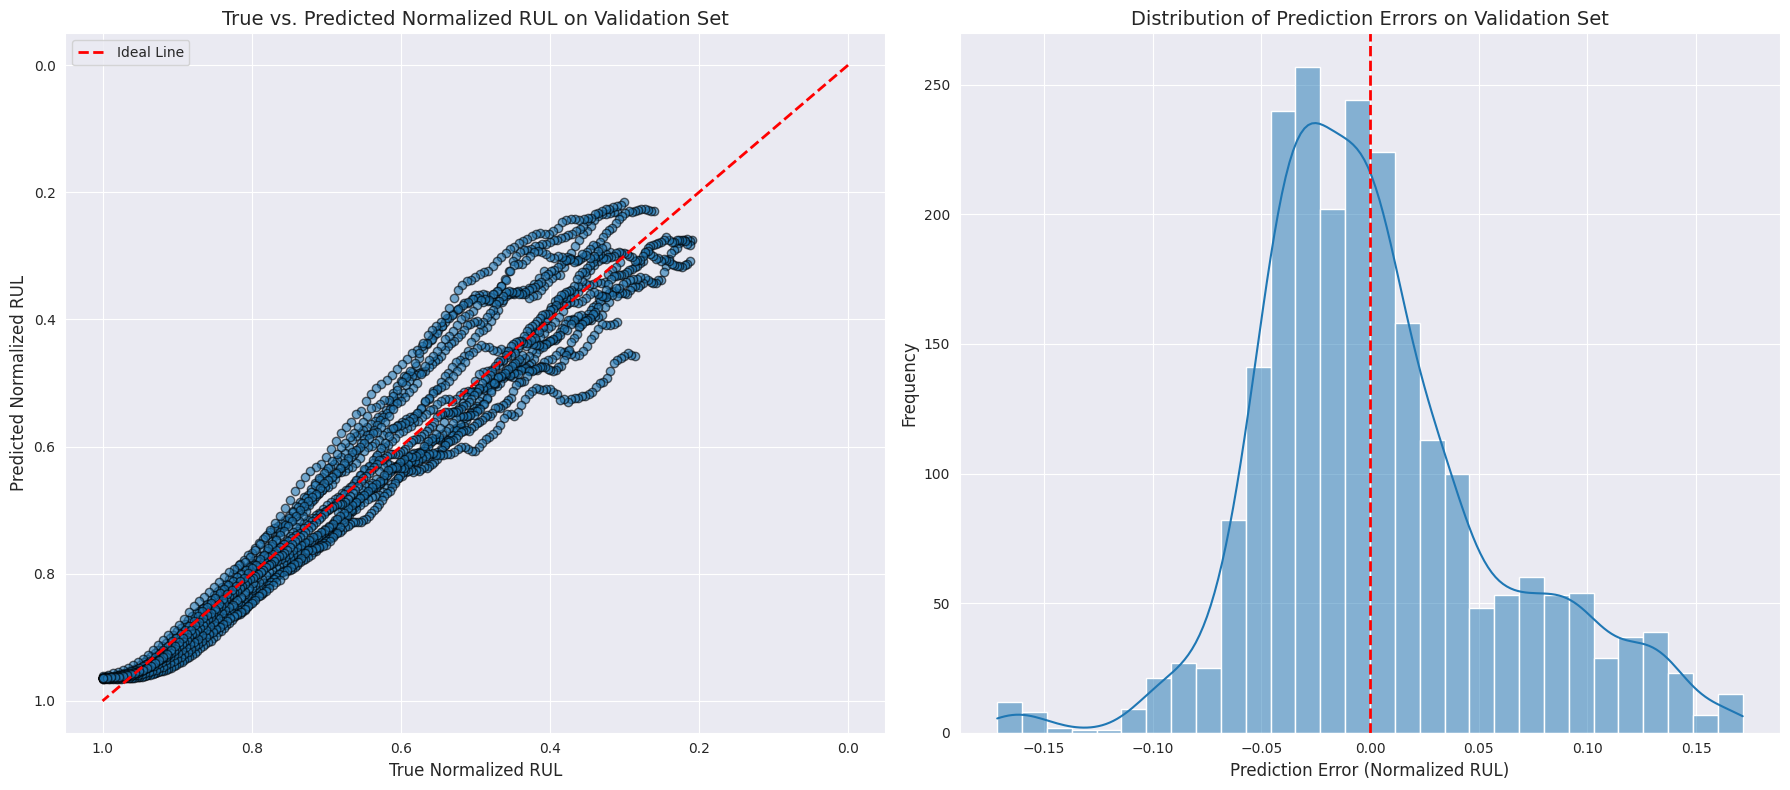

In [12]:
model.eval()
y_pred_list_val = []
with torch.no_grad():
    for batch_X, _ in val_loader:
        batch_X = batch_X.to(device)
        output = model(batch_X)
        y_pred_list_val.append(output.cpu().numpy())

y_pred_val = np.concatenate(y_pred_list_val, axis=0).flatten()
y_val_np_flat = y_val_np.flatten()
mae_val = mean_absolute_error(y_val_np_flat, y_pred_val)
rmse_val = np.sqrt(mean_squared_error(y_val_np_flat, y_pred_val))

print("\n--- Validation Set Performance ---")
print(f"Validation MAE (normalized): {mae_val:.4f}")
print(f"Validation RMSE (normalized): {rmse_val:.4f}\n")

plt.figure(figsize=(18, 8))
plt.subplot(1, 2, 1)
plt.scatter(y_val_np_flat, y_pred_val, alpha=0.6, edgecolors='k')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Ideal Line')
plt.title('True vs. Predicted Normalized RUL on Validation Set', fontsize=14)
plt.xlabel('True Normalized RUL', fontsize=12)
plt.ylabel('Predicted Normalized RUL', fontsize=12)
plt.grid(True)
plt.legend()

plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

errors_val = y_val_np_flat - y_pred_val
plt.subplot(1, 2, 2)
sns.histplot(errors_val, bins=30, kde=True)
plt.title('Distribution of Prediction Errors on Validation Set', fontsize=14)
plt.xlabel('Prediction Error (Normalized RUL)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', lw=2)
plt.grid(True)
plt.tight_layout()
plt.show()


--- Final Test Set Performance (RUL in cycles) ---
Test MAE (cycles):  8.19
Test RMSE (cycles): 10.63



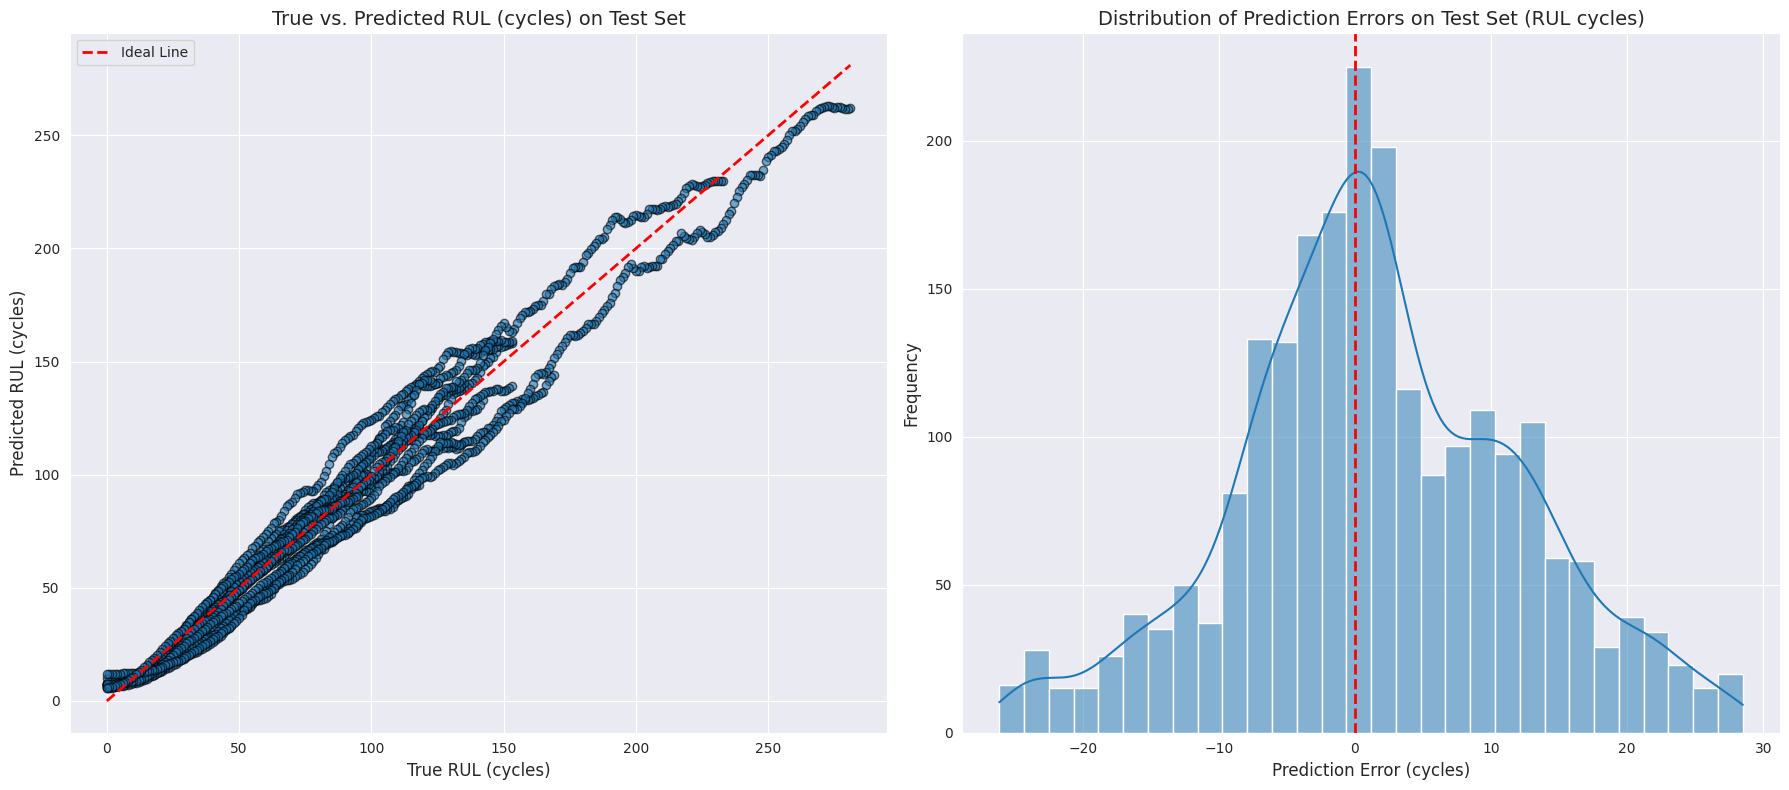

In [13]:
test_max_cycles      = window_aligned_max_cycles(test_df, LOOKBACK)
y_test_rul_true      = test_max_cycles * (1.0 - y_test_np_flat)
y_test_rul_pred      = test_max_cycles * (1.0 - y_pred_test)

mae_test_rul  = mean_absolute_error(y_test_rul_true, y_test_rul_pred)
rmse_test_rul = np.sqrt(mean_squared_error(y_test_rul_true, y_test_rul_pred))

print("\n--- Final Test Set Performance (RUL in cycles) ---")
print(f"Test MAE (cycles):  {mae_test_rul:.2f}")
print(f"Test RMSE (cycles): {rmse_test_rul:.2f}\n")

plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)
plt.scatter(y_test_rul_true, y_test_rul_pred, alpha=0.6, edgecolors='k')
m = float(max(y_test_rul_true.max(), y_test_rul_pred.max()))
plt.plot([0, m], [0, m], color='red', linestyle='--', lw=2, label='Ideal Line')
plt.title('True vs. Predicted RUL (cycles) on Test Set', fontsize=14)
plt.xlabel('True RUL (cycles)', fontsize=12)
plt.ylabel('Predicted RUL (cycles)', fontsize=12)
plt.grid(True); plt.legend()

plt.subplot(1, 2, 2)
errors_test_rul = y_test_rul_true - y_test_rul_pred
sns.histplot(errors_test_rul, bins=30, kde=True)
plt.title('Distribution of Prediction Errors on Test Set (RUL cycles)', fontsize=14)
plt.xlabel('Prediction Error (cycles)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', lw=2)
plt.grid(True)

plt.tight_layout(); plt.show()



--- Validation Set Performance (RUL in cycles) ---
Validation MAE (cycles):  9.04
Validation RMSE (cycles): 11.64



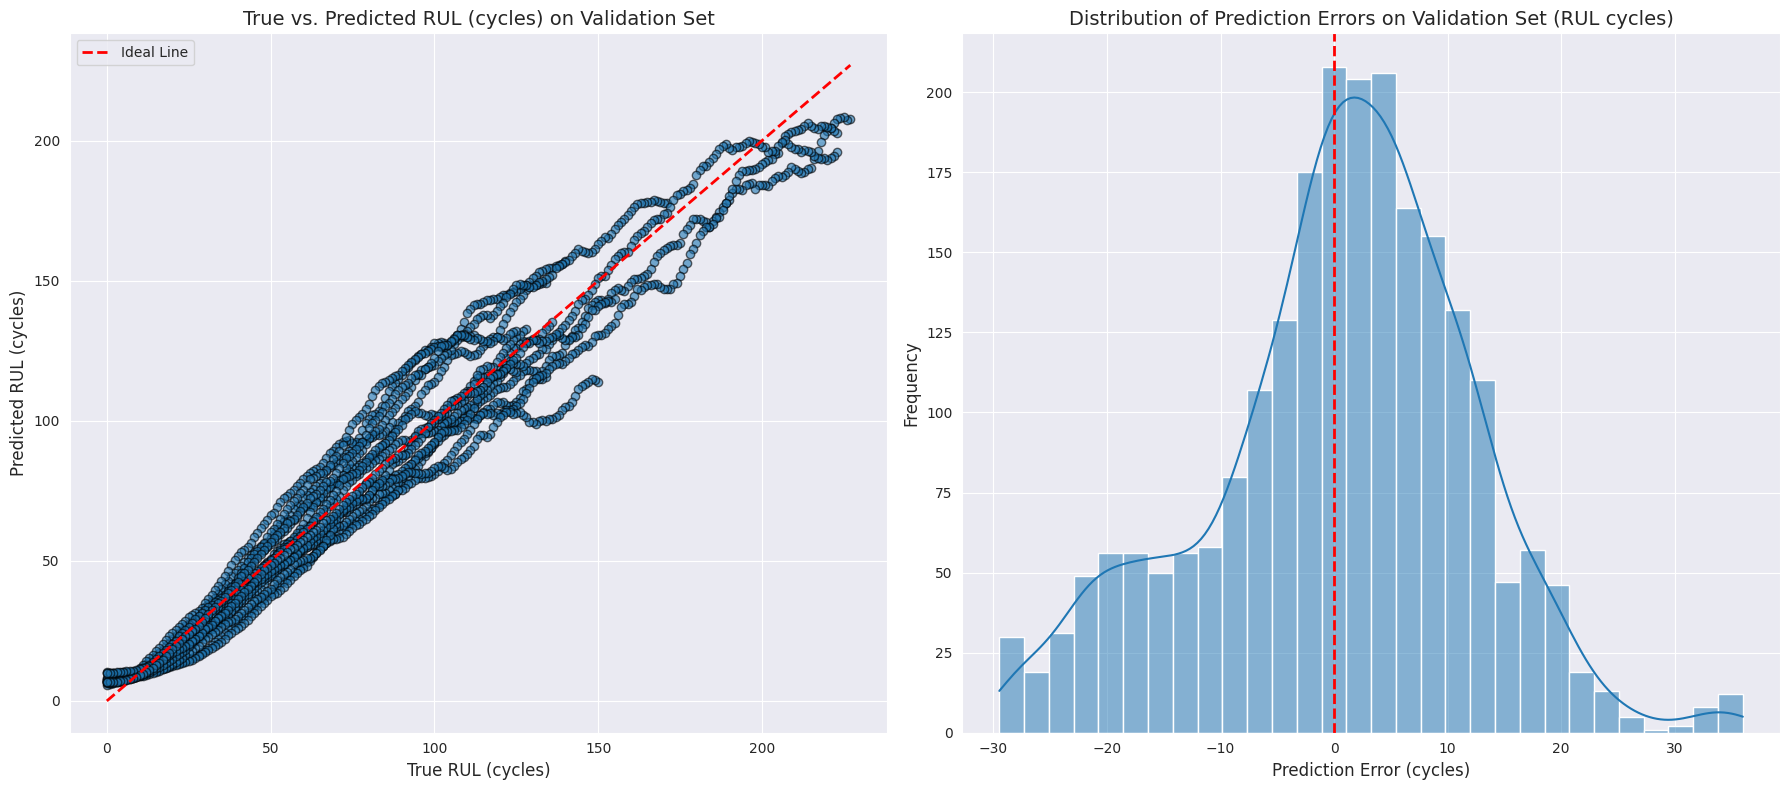

In [14]:
val_max_cycles      = window_aligned_max_cycles(val_df, LOOKBACK)
y_val_rul_true      = val_max_cycles * (1.0 - y_val_np_flat)
y_val_rul_pred      = val_max_cycles * (1.0 - y_pred_val)

mae_val_rul  = mean_absolute_error(y_val_rul_true, y_val_rul_pred)
rmse_val_rul = np.sqrt(mean_squared_error(y_val_rul_true, y_val_rul_pred))

print("\n--- Validation Set Performance (RUL in cycles) ---")
print(f"Validation MAE (cycles):  {mae_val_rul:.2f}")
print(f"Validation RMSE (cycles): {rmse_val_rul:.2f}\n")

plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)
plt.scatter(y_val_rul_true, y_val_rul_pred, alpha=0.6, edgecolors='k')
m = float(max(y_val_rul_true.max(), y_val_rul_pred.max()))
plt.plot([0, m], [0, m], color='red', linestyle='--', lw=2, label='Ideal Line')
plt.title('True vs. Predicted RUL (cycles) on Validation Set', fontsize=14)
plt.xlabel('True RUL (cycles)', fontsize=12)
plt.ylabel('Predicted RUL (cycles)', fontsize=12)
plt.grid(True); plt.legend()

plt.subplot(1, 2, 2)
errors_val_rul = y_val_rul_true - y_val_rul_pred
sns.histplot(errors_val_rul, bins=30, kde=True)
plt.title('Distribution of Prediction Errors on Validation Set (RUL cycles)', fontsize=14)
plt.xlabel('Prediction Error (cycles)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', lw=2)
plt.grid(True)

plt.tight_layout(); plt.show()


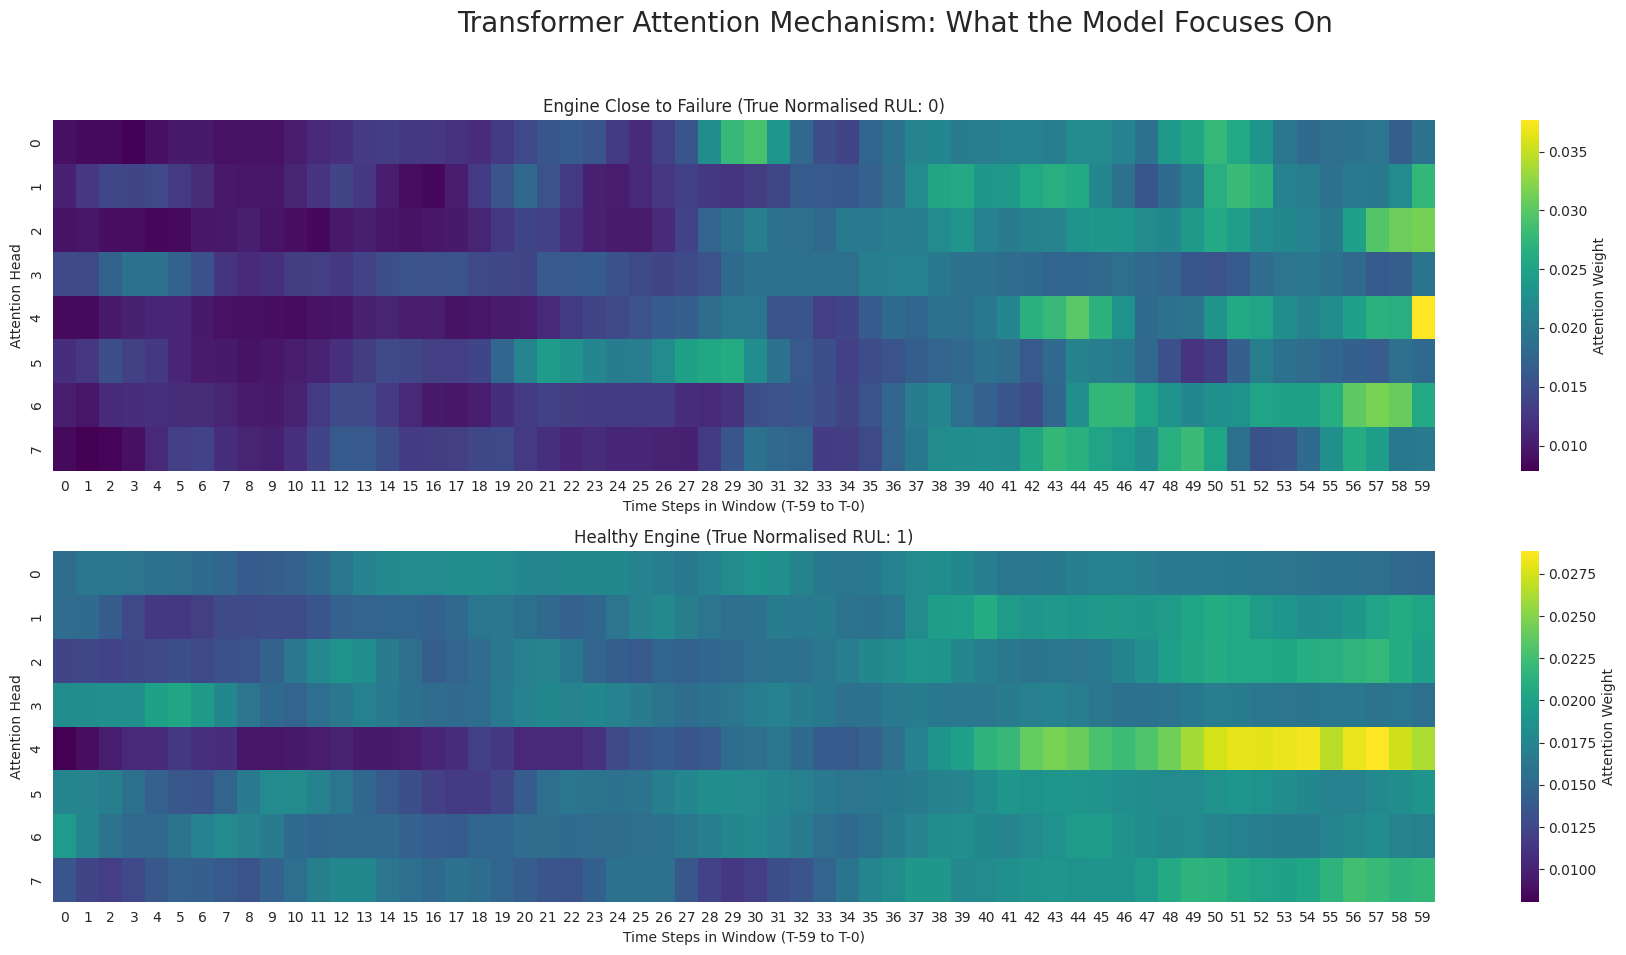

In [15]:
ef get_attention_map(model, sample):
    model.eval()
    with torch.no_grad():
        x = sample.permute(0, 2, 1)
        x = model.cnn(x)
        x = x.permute(0, 2, 1)
        x = model.pos(x)

        for i in range(len(model.transformer.layers) - 1):
            x = model.transformer.layers[i](x)

        last_layer = model.transformer.layers[-1]

        pre_sa_x = last_layer.norm1(x)


        _, attn_weights = last_layer.self_attn(
            pre_sa_x, pre_sa_x, pre_sa_x,
            need_weights=True,
            average_attn_weights=False
        )
        return attn_weights.cpu().squeeze(0)

y_test_series = pd.Series(y_test_np_flat)
low_rul_idx = y_test_series.idxmin()
high_rul_idx = y_test_series.idxmax()


low_rul_sample = X_test[low_rul_idx].unsqueeze(0).to(device)
high_rul_sample = X_test[high_rul_idx].unsqueeze(0).to(device)

low_rul_true_val = y_test_np_flat[low_rul_idx]
high_rul_true_val = y_test_np_flat[high_rul_idx]

low_rul_attn_heads = get_attention_map(model, low_rul_sample)
high_rul_attn_heads = get_attention_map(model, high_rul_sample)

low_rul_attn_avg = low_rul_attn_heads.mean(dim=1)
high_rul_attn_avg = high_rul_attn_heads.mean(dim=1)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10))
fig.suptitle('Transformer Attention Mechanism: What the Model Focuses On', fontsize=20)


sns.heatmap(low_rul_attn_avg, cmap='viridis', ax=ax1, cbar_kws={'label': 'Attention Weight'})
ax1.set_title(f'Engine Close to Failure (True Normalised RUL: {low_rul_true_val:.0f})')
ax1.set_xlabel('Time Steps in Window (T-59 to T-0)')
ax1.set_ylabel('Attention Head')

sns.heatmap(high_rul_attn_avg, cmap='viridis', ax=ax2, cbar_kws={'label': 'Attention Weight'})
ax2.set_title(f'Healthy Engine (True Normalised RUL: {high_rul_true_val:.0f})')
ax2.set_xlabel('Time Steps in Window (T-59 to T-0)')
ax2.set_ylabel('Attention Head')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()